In [1]:
import random, time, numpy as np, torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root='data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(
    root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 275kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.32MB/s]


In [2]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # STUDENT: define three trainable Linear layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)
        self.activation = nn.ReLU()

    def forward(self, x):
        # STUDENT: flatten, apply Layer 1 + activation,
        # Layer 2 + activation, then Layer 3 logits
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits

model = FashionMLP().to(device)
print(model)


FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)


Layer 1 uses 784 inputs because the picture has 28x28 pixels, which is a 2 dimensional matrix and it needs to be flattened into a one-dimensional vector. Since it has 28x28 pixels, the total is 784, so the first layer requires 784 input neurons. ReLU was use because this helps the model focus on importamt signals and makes training faster. Layer 3 has 10 outputs because Fashion-MNIST has 10 classes. Each output neuron produces one logit corresponding to one class. Logits are basically raw scores, and when the model returns logits, the loss function will use them to check how wrong the prediction is by comparing it with the correct answer.

In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear previous gradients
        logits = model(images)         # forward propagation
        loss = criterion(logits, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # parameter update

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


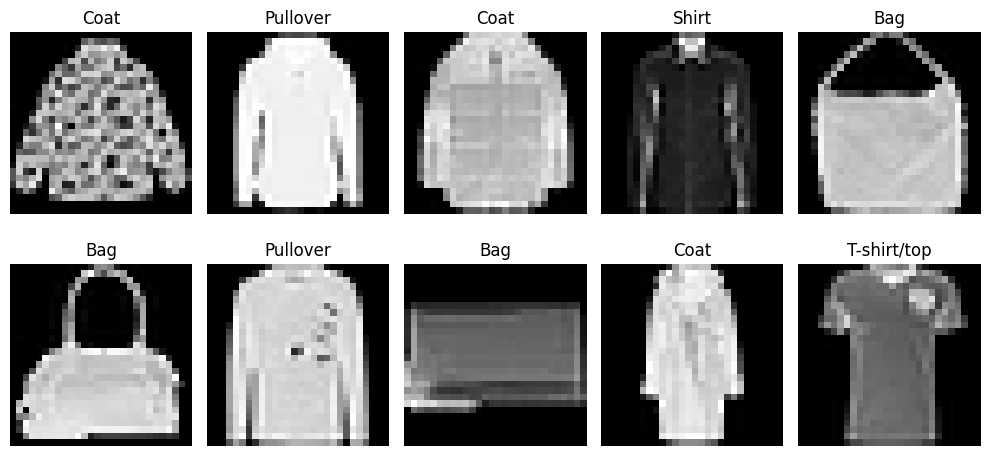

In [4]:
import matplotlib.pyplot as plt

classes = train_data.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Print model architecture
print(model)

# Print exact trainable parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")

# Print tensor shapes
images, labels = next(iter(train_loader))

print(f"\nInput Shape: {images.shape}")

x = model.flatten(images)
print(f"After Flatten: {x.shape}")

x = model.activation(model.fc1(x))
print(f"After Layer 1: {x.shape}")

x = model.activation(model.fc2(x))
print(f"After Layer 2: {x.shape}")

x = model.fc3(x)
print(f"After Layer 3 (Logits): {x.shape}")

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)

Total Trainable Parameters: 109386

Input Shape: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 128])
After Layer 2: torch.Size([64, 64])
After Layer 3 (Logits): torch.Size([64, 10])


In [6]:
def evaluate(model, loader):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 | Train Loss: 0.5127 | Test Loss: 0.4187 | Train Acc: 0.8172 | Test Acc: 0.8481
Epoch 2/10 | Train Loss: 0.3788 | Test Loss: 0.4063 | Train Acc: 0.8609 | Test Acc: 0.8523
Epoch 3/10 | Train Loss: 0.3370 | Test Loss: 0.3592 | Train Acc: 0.8774 | Test Acc: 0.8704
Epoch 4/10 | Train Loss: 0.3138 | Test Loss: 0.3638 | Train Acc: 0.8834 | Test Acc: 0.8693
Epoch 5/10 | Train Loss: 0.2953 | Test Loss: 0.3482 | Train Acc: 0.8903 | Test Acc: 0.8735
Epoch 6/10 | Train Loss: 0.2815 | Test Loss: 0.3504 | Train Acc: 0.8953 | Test Acc: 0.8737
Epoch 7/10 | Train Loss: 0.2680 | Test Loss: 0.3626 | Train Acc: 0.9004 | Test Acc: 0.8720
Epoch 8/10 | Train Loss: 0.2567 | Test Loss: 0.3394 | Train Acc: 0.9036 | Test Acc: 0.8830
Epoch 9/10 | Train Loss: 0.2461 | Test Loss: 0.3377 | Train Acc: 0.9090 | Test Acc: 0.8802
Epoch 10/10 | Train Loss: 0.2349 | Test Loss: 0.3368 | Train Acc: 0.9107 | Test Acc: 0.8869
